In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

for folder in ["data/splits", "data/processed", "results/checkpoints", "results/plots"]:
    os.makedirs(folder, exist_ok=True)

Device: cpu


# **Load MTAT tags and filter to top-50 : reads annotations_final.csv, builds mtat_df**

In [2]:
mtat_root = "/kaggle/input/datasets/yalumusic/magnatagatune"
audio_dir = f"{mtat_root}/MagnaTagATune"

tags_df = pd.read_csv(f"{mtat_root}/annotations_final.csv", sep="\t")
tag_columns = tags_df.columns[1:-1]
tag_counts = tags_df[tag_columns].sum().sort_values(ascending=False)
top_50_tags = tag_counts.head(50).index.tolist()

mtat_df = tags_df[tags_df[top_50_tags].sum(axis=1) > 0].reset_index(drop=True)
mtat_df["folder"] = mtat_df["mp3_path"].str.split("/").str[0]

print("Clips after filtering:", len(mtat_df))

Clips after filtering: 21111


# **MTAT train/val/test split by folder: splits using MagnaTagATune's standard folder convention**

In [3]:
train_folders = list("0123456789ab")
val_folders = ["c"]
test_folders = ["d", "e", "f"]

train_df = mtat_df[mtat_df["folder"].isin(train_folders)].reset_index(drop=True)
val_df = mtat_df[mtat_df["folder"].isin(val_folders)].reset_index(drop=True)
test_df = mtat_df[mtat_df["folder"].isin(test_folders)].reset_index(drop=True)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

Train: 15250 | Val: 1529 | Test: 4332


# **Section: Feature extraction and graph-building functions**

# **Audio loading and feature extraction functions : load_audio, get_melspectrogram, get_chroma, split_into_segments**

In [4]:
def load_audio(path, sr=22050):
    y, sr = librosa.load(path, sr=sr, mono=True)
    return y, sr

def get_melspectrogram(y, sr, n_mels=128):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=1.0).T
    mean = log_mel.mean(axis=0, keepdims=True)
    std = log_mel.std(axis=0, keepdims=True) + 1e-8
    return (log_mel - mean) / std

def get_chroma(y, sr, n_chroma=12):
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=n_chroma).T
    mean = chroma.mean(axis=0, keepdims=True)
    std = chroma.std(axis=0, keepdims=True) + 1e-8
    return (chroma - mean) / std

def split_into_segments(feature_matrix, sr, hop_length=512, window_seconds=5.0):
    frames_per_segment = int(window_seconds * sr / hop_length)
    segments = []
    for start in range(0, feature_matrix.shape[0], frames_per_segment):
        chunk = feature_matrix[start:start + frames_per_segment]
        if len(chunk) > 0:
            segments.append(chunk.mean(axis=0))
    return segments

# **Segment-similarity graph construction : cosine_similarity, build_segment_graph**

In [5]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def build_segment_graph(segments, similarity_threshold=0.5):
    n = len(segments)
    edges = set()
    for i in range(n - 1):
        edges.add((i, i + 1))
    for i in range(n):
        for j in range(i + 1, n):
            if cosine_similarity(segments[i], segments[j]) > similarity_threshold:
                edges.add((i, j))
    return list(edges)

# **Sanity check**

In [6]:
print("mtat_df rows:", len(mtat_df))
print("top_50_tags count:", len(top_50_tags))
print("train/val/test sizes:", len(train_df), len(val_df), len(test_df))
print("Functions ready:", all(name in dir() for name in
      ["load_audio", "get_melspectrogram", "get_chroma", "split_into_segments",
       "cosine_similarity", "build_segment_graph"]))

mtat_df rows: 21111
top_50_tags count: 50
train/val/test sizes: 15250 1529 4332
Functions ready: False


# **Timing benchmark on 100 sample clips**

In [7]:
import time

sample_paths = train_df["mp3_path"].iloc[:100].tolist()

start = time.time()
for path in sample_paths:
    y, sr = load_audio(f"{audio_dir}/{path}")
    mel = get_melspectrogram(y, sr)
    segments = split_into_segments(mel, sr)
    edges = build_segment_graph(segments)
elapsed = time.time() - start

per_clip = elapsed / 100
print(f"Time for 100 clips: {elapsed:.1f}s  ->  {per_clip:.3f}s/clip")
print(f"Estimated time for 8,000 clips: {per_clip * 8000 / 60:.1f} minutes")

Time for 100 clips: 28.9s  ->  0.289s/clip
Estimated time for 8,000 clips: 38.5 minutes


# **Section: MTAT graph caching**

# **Install PyTorch Geometric + define per-clip graph caching function**

In [8]:
!pip install -q torch_geometric

from torch_geometric.data import Data

def process_and_cache_clip(mp3_path, save_path):
    y, sr = load_audio(f"{audio_dir}/{mp3_path}")
    mel = get_melspectrogram(y, sr)
    segments = split_into_segments(mel, sr)
    edges = build_segment_graph(segments)

    x = torch.tensor(np.array(segments), dtype=torch.float32)
    if len(edges) == 0:
        edge_index = torch.tensor([[0], [0]], dtype=torch.long)  # single-segment fallback: self-loop
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    graph = Data(x=x, edge_index=edge_index)
    torch.save(graph, save_path)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.9 MB/s eta 0:00:00


In [9]:
import torch_geometric
print("torch_geometric version:", torch_geometric.__version__)
print("torch version:", torch.__version__)

torch_geometric version: 2.8.0.post1
torch version: 2.10.0+cpu


# **Cache all MTAT clips as PyG graph objects**

In [10]:
import time

clips_to_cache = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
print("Total clips to cache:", len(clips_to_cache))

start = time.time()
processed, skipped, failed = 0, 0, 0

for i, row in clips_to_cache.iterrows():
    save_path = f"data/processed/{row['clip_id']}.pt"
    if os.path.exists(save_path):
        skipped += 1
        continue

    try:
        process_and_cache_clip(row["mp3_path"], save_path)
        processed += 1
    except Exception as e:
        failed += 1
        print(f"Failed on {row['mp3_path']}: {e}")

    if (i + 1) % 1000 == 0:
        elapsed = (time.time() - start) / 60
        print(f"{i+1}/{len(clips_to_cache)} | processed {processed}, skipped {skipped}, failed {failed} | {elapsed:.1f} min elapsed")

print(f"Done. Processed {processed}, skipped {skipped}, failed {failed}. Total time: {(time.time()-start)/60:.1f} min")

Total clips to cache: 21111
1000/21111 | processed 1000, skipped 0, failed 0 | 1.6 min elapsed
2000/21111 | processed 2000, skipped 0, failed 0 | 3.2 min elapsed
3000/21111 | processed 3000, skipped 0, failed 0 | 4.8 min elapsed
4000/21111 | processed 4000, skipped 0, failed 0 | 6.4 min elapsed
5000/21111 | processed 5000, skipped 0, failed 0 | 8.0 min elapsed
6000/21111 | processed 6000, skipped 0, failed 0 | 9.6 min elapsed
7000/21111 | processed 7000, skipped 0, failed 0 | 11.2 min elapsed
8000/21111 | processed 8000, skipped 0, failed 0 | 12.8 min elapsed
9000/21111 | processed 9000, skipped 0, failed 0 | 14.4 min elapsed


/tmp/ipykernel_17/4107278170.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Failed on 6/norine_braun-now_and_zen-08-gently-117-146.mp3: 
10000/21111 | processed 9999, skipped 0, failed 1 | 16.1 min elapsed
11000/21111 | processed 10999, skipped 0, failed 1 | 17.7 min elapsed
12000/21111 | processed 11999, skipped 0, failed 1 | 19.3 min elapsed
13000/21111 | processed 12999, skipped 0, failed 1 | 20.9 min elapsed
14000/21111 | processed 13999, skipped 0, failed 1 | 22.5 min elapsed
Failed on 8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3: 
15000/21111 | processed 14998, skipped 0, failed 2 | 24.1 min elapsed
Failed on 9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3: 
16000/21111 | processed 15997, skipped 0, failed 3 | 25.7 min elapsed
17000/21111 | processed 16997, skipped 0, failed 3 | 27.4 min elapsed
18000/21111 | processed 17997, skipped 0, failed 3 | 29.0 min elapsed
19000/21111 | processed 18997, skipped 0, failed 3 | 30.6 min elapsed
20000/21111 | proce

# **Drop failed clips from MTAT splits**

In [11]:
failed_paths = [
    "6/norine_braun-now_and_zen-08-gently-117-146.mp3",
    "8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3",
    "9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3",
]

train_df = train_df[~train_df["mp3_path"].isin(failed_paths)].reset_index(drop=True)
val_df = val_df[~val_df["mp3_path"].isin(failed_paths)].reset_index(drop=True)
test_df = test_df[~test_df["mp3_path"].isin(failed_paths)].reset_index(drop=True)

print("New sizes — train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

New sizes — train: 15247 val: 1529 test: 4332


# **Copy example graphs for inspection**

In [12]:
os.makedirs("data/processed/example_graphs", exist_ok=True)

import shutil
example_clip_ids = train_df["clip_id"].iloc[:20].tolist()

for clip_id in example_clip_ids:
    src = f"data/processed/{clip_id}.pt"
    dst = f"data/processed/example_graphs/{clip_id}.pt"
    shutil.copy(src, dst)

print("Copied", len(os.listdir("data/processed/example_graphs")), "example graphs.")

Copied 20 example graphs.


# **Section: GTZAN setup and graph caching**

In [13]:
gtzan_root = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data"
print(os.listdir(gtzan_root))

['features_3_sec.csv', 'features_30_sec.csv', 'images_original', 'genres_original']


# **Build GTZAN file index with genre labels**

In [14]:
genres_dir = f"{gtzan_root}/genres_original"  
genre_names = sorted(os.listdir(genres_dir))
print("Genres found:", genre_names)

gtzan_files = []
for genre in genre_names:
    genre_folder = f"{genres_dir}/{genre}"
    for filename in os.listdir(genre_folder):
        if filename.endswith(".wav"):
            gtzan_files.append({"path": f"{genre_folder}/{filename}", "genre": genre})

gtzan_df = pd.DataFrame(gtzan_files)
print("Total clips:", len(gtzan_df))
print(gtzan_df["genre"].value_counts())

Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total clips: 1000
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


# **Stratified train/val/test split for GTZAN**

In [15]:
from sklearn.model_selection import train_test_split

genre_to_idx = {g: i for i, g in enumerate(genre_names)}
gtzan_df["label"] = gtzan_df["genre"].map(genre_to_idx)
gtzan_df["clip_id"] = gtzan_df.index  # <-- ADD THIS LINE HERE

gtzan_train, gtzan_temp = train_test_split(gtzan_df, test_size=0.3, stratify=gtzan_df["genre"], random_state=42)
gtzan_val, gtzan_test = train_test_split(gtzan_temp, test_size=2/3, stratify=gtzan_temp["genre"], random_state=42)

print("Train:", len(gtzan_train), "Val:", len(gtzan_val), "Test:", len(gtzan_test))

Train: 700 Val: 100 Test: 200


# **Cache GTZAN clips as PyG graph objects : reuses MTAT graph-building logic**

In [16]:
os.makedirs("data/processed/gtzan", exist_ok=True)
gtzan_df = gtzan_df.reset_index(drop=True)
gtzan_df["clip_id"] = gtzan_df.index  # simple integer id, since GTZAN has no clip_id column like MTAT

def process_and_cache_gtzan_clip(mp3_path, save_path):
    y, sr = load_audio(mp3_path) 
    mel = get_melspectrogram(y, sr)
    segments = split_into_segments(mel, sr)
    edges = build_segment_graph(segments)

    x = torch.tensor(np.array(segments), dtype=torch.float32)
    edge_index = torch.tensor([[0], [0]], dtype=torch.long) if len(edges) == 0 else torch.tensor(edges, dtype=torch.long).t().contiguous()
    torch.save(Data(x=x, edge_index=edge_index), save_path)

processed, failed = 0, 0
for i, row in gtzan_df.iterrows():
    save_path = f"data/processed/gtzan/{row['clip_id']}.pt"
    if os.path.exists(save_path):
        continue
    try:
        process_and_cache_gtzan_clip(row["path"], save_path)
        processed += 1
    except Exception as e:
        failed += 1
        print(f"Failed on {row['path']}: {e}")

print(f"Done. Processed {processed}, failed {failed}.")

/tmp/ipykernel_17/4107278170.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Failed on /kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00054.wav: 
Done. Processed 999, failed 1.


# **Drop failed clip from GTZAN train split**

In [17]:
gtzan_df["clip_id"] = gtzan_df.index  # add this BEFORE splitting this time

from sklearn.model_selection import train_test_split

gtzan_train, gtzan_temp = train_test_split(gtzan_df, test_size=0.3, stratify=gtzan_df["genre"], random_state=42)
gtzan_val, gtzan_test = train_test_split(gtzan_temp, test_size=2/3, stratify=gtzan_temp["genre"], random_state=42)

failed_path = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00054.wav"
gtzan_train = gtzan_train[gtzan_train["path"] != failed_path].reset_index(drop=True)
gtzan_val = gtzan_val[gtzan_val["path"] != failed_path].reset_index(drop=True)
gtzan_test = gtzan_test[gtzan_test["path"] != failed_path].reset_index(drop=True)

print("Train:", len(gtzan_train), "Val:", len(gtzan_val), "Test:", len(gtzan_test))
print("clip_id present:", "clip_id" in gtzan_train.columns)

Train: 699 Val: 100 Test: 200
clip_id present: True


# **Section: MTAT tag classification : dataset and model**

# **MTAT graph dataset class : GraphTagDataset, wraps cached graphs with multi-hot tag labels**

In [18]:
from torch_geometric.loader import DataLoader as GeoDataLoader

class GraphTagDataset(torch.utils.data.Dataset):
    def __init__(self, df, tag_columns):
        self.df = df.reset_index(drop=True)
        self.tag_columns = tag_columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        graph = torch.load(f"data/processed/{row['clip_id']}.pt", weights_only=False)
        label = row[self.tag_columns].values.astype("float32")
        graph.y = torch.tensor(label).unsqueeze(0)  # attach the label directly to the graph object
        return graph

# **Sanity check: inspect one training batch shape**

In [19]:
train_graph_dataset = GraphTagDataset(train_df, top_50_tags)
train_graph_loader = GeoDataLoader(train_graph_dataset, batch_size=32, shuffle=True)

batch = next(iter(train_graph_loader))
print("Node features shape:", batch.x.shape)
print("Edge index shape:", batch.edge_index.shape)
print("Labels shape:", batch.y.shape)
print("Batch vector shape:", batch.batch.shape)
print("Number of graphs in this batch:", batch.num_graphs)

Node features shape: torch.Size([192, 128])
Edge index shape: torch.Size([2, 250])
Labels shape: torch.Size([32, 50])
Batch vector shape: torch.Size([192])
Number of graphs in this batch: 32


# **GNN encoder definition : GNNEncoder, GraphSAGE-based, reused across MTAT and GTZAN**

In [20]:
from torch_geometric.nn import SAGEConv, global_mean_pool

class GNNEncoder(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        dims = [in_dim] + [hidden_dim] * num_layers
        for i in range(num_layers):
            self.convs.append(SAGEConv(dims[i], dims[i + 1]))
        self.dropout = dropout
        self.out_dim = hidden_dim

    def forward(self, x, edge_index, batch):
        h = x
        for i, conv in enumerate(self.convs):
            h = conv(h, edge_index)
            if i < len(self.convs) - 1:
                h = torch.relu(h)
                h = nn.functional.dropout(h, p=self.dropout, training=self.training)
        graph_vector = global_mean_pool(h, batch)  # one vector per graph, mean over its nodes
        return graph_vector

# **MTAT tag classification head : GNNTagClassifier**

In [21]:
class GNNTagClassifier(nn.Module):
    def __init__(self, encoder, num_tags=50):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.out_dim, num_tags)

    def forward(self, x, edge_index, batch):
        graph_vector = self.encoder(x, edge_index, batch)
        return self.classifier(graph_vector)

# **Sanity check: forward pass and loss on one batch**

In [22]:
encoder = GNNEncoder(in_dim=128, hidden_dim=64, num_layers=2)
model = GNNTagClassifier(encoder, num_tags=50).to(device)

batch = batch.to(device)
logits = model(batch.x, batch.edge_index, batch.batch)

print("Logits shape:", logits.shape)
print("Labels shape:", batch.y.shape)

loss_fn = nn.BCEWithLogitsLoss()
loss = loss_fn(logits, batch.y)
print("Loss:", loss.item())

Logits shape: torch.Size([32, 50])
Labels shape: torch.Size([32, 50])
Loss: 0.694872260093689


# **Evaluation function for multi-label metrics : evaluate_gnn (macro-F1, micro-F1, PR-AUC)**

In [23]:
@torch.no_grad()
def evaluate_gnn(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    probs = torch.sigmoid(all_logits).numpy()
    preds = (probs > 0.5).astype(int)
    labels_np = all_labels.numpy()

    return {
        "macro_f1": f1_score(labels_np, preds, average="macro", zero_division=0),
        "micro_f1": f1_score(labels_np, preds, average="micro", zero_division=0),
        "pr_auc": average_precision_score(labels_np, probs, average="macro"),
    }

# **Build val/test loaders for MTAT**

In [24]:
val_graph_dataset = GraphTagDataset(val_df, top_50_tags)
test_graph_dataset = GraphTagDataset(test_df, top_50_tags)

val_graph_loader = GeoDataLoader(val_graph_dataset, batch_size=32, shuffle=False)
test_graph_loader = GeoDataLoader(test_graph_dataset, batch_size=32, shuffle=False)

# **Section: MTAT GNN training**

In [25]:
from sklearn.metrics import f1_score, average_precision_score

def train_task2(train_loader, val_loader, test_loader, train_df, tag_columns, device, num_epochs=40, patience=8):
    # pos_weight: upweight rare tags in the loss so the model isn't rewarded
    # for just predicting "no" on everything. Standard fix for imbalanced
    # multi-label BCE -- ratio of negatives to positives, per tag.
    positive_counts = train_df[tag_columns].sum().values
    negative_counts = len(train_df) - positive_counts
    pos_weight = torch.tensor(negative_counts / (positive_counts + 1e-8), dtype=torch.float32).to(device)
    pos_weight = torch.clamp(pos_weight, max=20.0)  # cap it -- extreme weights destabilize training

    encoder = GNNEncoder(in_dim=128, hidden_dim=128, num_layers=3, dropout=0.2)  # bumped capacity a bit
    model = GNNTagClassifier(encoder, num_tags=len(tag_columns)).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_f1, best_state, best_epoch, epochs_without_improvement = 0.0, None, None, 0
    history = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss = loss_fn(logits, batch.y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_metrics = evaluate_gnn(model, val_loader, device)
        avg_train_loss = total_loss / len(train_loader)
        history.append({"epoch": epoch + 1, "train_loss": avg_train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}})

        print(f"Epoch {epoch+1} | train loss: {avg_train_loss:.4f} | "
              f"val macro-F1: {val_metrics['macro_f1']:.4f} | val PR-AUC: {val_metrics['pr_auc']:.4f}")

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1, best_epoch = val_metrics["macro_f1"], epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"No improvement for {patience} epochs — stopping early at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    test_metrics = evaluate_gnn(model, test_loader, device)
    print(f"Final test metrics (best epoch {best_epoch}):", test_metrics)
    return model, test_metrics, history, best_epoch

In [26]:
gnn_model, gnn_test_metrics, gnn_history, gnn_best_epoch = train_task2(
    train_graph_loader, val_graph_loader, test_graph_loader, train_df, top_50_tags, device, num_epochs=40, patience=8
)

Epoch 1 | train loss: 1.1401 | val macro-F1: 0.1681 | val PR-AUC: 0.1399
Epoch 2 | train loss: 1.0224 | val macro-F1: 0.2051 | val PR-AUC: 0.1732
Epoch 3 | train loss: 0.9583 | val macro-F1: 0.2218 | val PR-AUC: 0.1927
Epoch 4 | train loss: 0.9227 | val macro-F1: 0.2221 | val PR-AUC: 0.2103
Epoch 5 | train loss: 0.8919 | val macro-F1: 0.2352 | val PR-AUC: 0.2233
Epoch 6 | train loss: 0.8711 | val macro-F1: 0.2244 | val PR-AUC: 0.2250
Epoch 7 | train loss: 0.8496 | val macro-F1: 0.2346 | val PR-AUC: 0.2360
Epoch 8 | train loss: 0.8400 | val macro-F1: 0.2326 | val PR-AUC: 0.2369
Epoch 9 | train loss: 0.8254 | val macro-F1: 0.2440 | val PR-AUC: 0.2490
Epoch 10 | train loss: 0.8103 | val macro-F1: 0.2452 | val PR-AUC: 0.2526
Epoch 11 | train loss: 0.8029 | val macro-F1: 0.2541 | val PR-AUC: 0.2530
Epoch 12 | train loss: 0.7900 | val macro-F1: 0.2479 | val PR-AUC: 0.2570
Epoch 13 | train loss: 0.7846 | val macro-F1: 0.2460 | val PR-AUC: 0.2554
Epoch 14 | train loss: 0.7720 | val macro-F1: 0

# **Get raw probabilities/labels for threshold tuning**

In [27]:
@torch.no_grad()
def get_probs_labels_gnn(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    probs = torch.sigmoid(all_logits).numpy()
    labels_np = all_labels.numpy()
    return probs, labels_np

# **Threshold tuning: find best macro-F1 threshold on validation set**

In [28]:
val_probs, val_labels = get_probs_labels_gnn(gnn_model, val_graph_loader, device)

best_f1, best_threshold = 0, 0.5
for t in np.arange(0.02, 0.5, 0.02):
    preds = (val_probs > t).astype(int)
    f1 = f1_score(val_labels, preds, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print("Best threshold found on val:", best_threshold, "| val macro-F1 at that threshold:", best_f1)

test_probs, test_labels = get_probs_labels_gnn(gnn_model, test_graph_loader, device)
test_preds_tuned = (test_probs > best_threshold).astype(int)
tuned_test_f1 = f1_score(test_labels, test_preds_tuned, average="macro", zero_division=0)

print("Test macro-F1 at fixed 0.5:      ", gnn_test_metrics["macro_f1"])
print("Test macro-F1 at tuned threshold:", tuned_test_f1)

Best threshold found on val: 0.48000000000000004 | val macro-F1 at that threshold: 0.25430184836773195
Test macro-F1 at fixed 0.5:       0.2648811467664451
Test macro-F1 at tuned threshold: 0.26025439356583935


# **Save GNN checkpoint and training history**

In [29]:
import json

torch.save(gnn_model.state_dict(), "results/checkpoints/task2_gnn.pt")
with open("results/task2_training_history.json", "w") as f:
    json.dump(gnn_history, f, indent=2)

print("Saved.")

Saved.


# **Section: MTAT baselines**

# **B1 baseline: majority-class predictor**

In [30]:
tag_rates = train_df[top_50_tags].mean()
majority_pred_vector = (tag_rates > 0.5).astype(int).values

always_yes_tags = [tag for tag, val in zip(top_50_tags, majority_pred_vector) if val == 1]
print("Tags this baseline always predicts 'yes' for:", always_yes_tags)

n_test = len(test_df)
b1_preds = np.tile(majority_pred_vector, (n_test, 1))
b1_probs = np.tile(tag_rates.values, (n_test, 1))
test_labels_mtat = test_df[top_50_tags].values.astype(int)

b1_metrics = {
    "macro_f1": f1_score(test_labels_mtat, b1_preds, average="macro", zero_division=0),
    "micro_f1": f1_score(test_labels_mtat, b1_preds, average="micro", zero_division=0),
    "pr_auc": average_precision_score(test_labels_mtat, b1_probs, average="macro"),
}
print("B1 (majority-class):", b1_metrics)

Tags this baseline always predicts 'yes' for: []
B1 (majority-class): {'macro_f1': 0.0, 'micro_f1': 0.0, 'pr_auc': np.float64(0.06532317636195753)}


# **Segment-matrix dataset for CNN baseline**

In [31]:
def load_segment_matrix(clip_id, max_segments=8, n_features=128):
    graph = torch.load(f"data/processed/{clip_id}.pt", weights_only=False)
    x = graph.x.numpy()
    n_segments = x.shape[0]

    if n_segments >= max_segments:
        x = x[:max_segments]
    else:
        pad = np.zeros((max_segments - n_segments, n_features), dtype=np.float32)
        x = np.vstack([x, pad])
    return x


class SegmentMatrixDataset(Dataset):
    def __init__(self, df, tag_columns, max_segments=8):
        self.df = df.reset_index(drop=True)
        self.tag_columns = tag_columns
        self.max_segments = max_segments

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_segment_matrix(row["clip_id"], self.max_segments)
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # (1, max_segments, 128) — 1 channel, like a small image
        label = torch.tensor(row[self.tag_columns].values.astype("float32"))
        return x, label

# **CNN baseline model definition**

In [32]:
class CNNMelBaseline(nn.Module):
    def __init__(self, num_tags=50):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(32, num_tags)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.classifier(h)

# **Training loop for CNN baseline**

In [33]:
def train_task2_cnn(train_df, val_df, test_df, tag_columns, device, num_epochs=40, patience=8, max_segments=8):
    positive_counts = train_df[tag_columns].sum().values
    negative_counts = len(train_df) - positive_counts
    pos_weight = torch.tensor(negative_counts / (positive_counts + 1e-8), dtype=torch.float32).to(device)
    pos_weight = torch.clamp(pos_weight, max=20.0)

    model = CNNMelBaseline(num_tags=len(tag_columns)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_loader = DataLoader(SegmentMatrixDataset(train_df, tag_columns, max_segments), batch_size=32, shuffle=True)
    val_loader = DataLoader(SegmentMatrixDataset(val_df, tag_columns, max_segments), batch_size=32, shuffle=False)
    test_loader = DataLoader(SegmentMatrixDataset(test_df, tag_columns, max_segments), batch_size=32, shuffle=False)

    best_val_f1, best_state, best_epoch, epochs_without_improvement = 0.0, None, None, 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x, labels in train_loader:
            x, labels = x.to(device), labels.to(device)
            logits = model(x)
            loss = loss_fn(logits, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()

        model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for x, labels in val_loader:
                x = x.to(device)
                all_logits.append(model(x).cpu())
                all_labels.append(labels)
        val_probs = torch.sigmoid(torch.cat(all_logits)).numpy()
        val_labels_np = torch.cat(all_labels).numpy()
        val_f1 = f1_score(val_labels_np, (val_probs > 0.5).astype(int), average="macro", zero_division=0)

        print(f"Epoch {epoch+1} | train loss: {total_loss/len(train_loader):.4f} | val macro-F1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1, best_epoch = val_f1, epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"No improvement for {patience} epochs — stopping early at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, labels in test_loader:
            x = x.to(device)
            all_logits.append(model(x).cpu())
            all_labels.append(labels)
    test_probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    test_labels_np = torch.cat(all_labels).numpy()
    test_preds = (test_probs > 0.5).astype(int)

    test_metrics = {
        "macro_f1": f1_score(test_labels_np, test_preds, average="macro", zero_division=0),
        "micro_f1": f1_score(test_labels_np, test_preds, average="micro", zero_division=0),
        "pr_auc": average_precision_score(test_labels_np, test_probs, average="macro"),
    }
    print(f"Final test metrics (best epoch {best_epoch}):", test_metrics)
    return model, test_metrics

# **Train B2 (CNN-mel) baseline and save checkpoint**

In [34]:
b2_model, b2_metrics = train_task2_cnn(train_df, val_df, test_df, top_50_tags, device, num_epochs=80, patience=8)

Epoch 1 | train loss: 1.1616 | val macro-F1: 0.1257
Epoch 2 | train loss: 1.1224 | val macro-F1: 0.1322
Epoch 3 | train loss: 1.1075 | val macro-F1: 0.1409
Epoch 4 | train loss: 1.1005 | val macro-F1: 0.1400
Epoch 5 | train loss: 1.0949 | val macro-F1: 0.1492
Epoch 6 | train loss: 1.0893 | val macro-F1: 0.1520
Epoch 7 | train loss: 1.0834 | val macro-F1: 0.1552
Epoch 8 | train loss: 1.0789 | val macro-F1: 0.1557
Epoch 9 | train loss: 1.0751 | val macro-F1: 0.1606
Epoch 10 | train loss: 1.0710 | val macro-F1: 0.1601
Epoch 11 | train loss: 1.0680 | val macro-F1: 0.1589
Epoch 12 | train loss: 1.0659 | val macro-F1: 0.1656
Epoch 13 | train loss: 1.0640 | val macro-F1: 0.1660
Epoch 14 | train loss: 1.0616 | val macro-F1: 0.1678
Epoch 15 | train loss: 1.0609 | val macro-F1: 0.1646
Epoch 16 | train loss: 1.0600 | val macro-F1: 0.1645
Epoch 17 | train loss: 1.0578 | val macro-F1: 0.1655
Epoch 18 | train loss: 1.0579 | val macro-F1: 0.1703
Epoch 19 | train loss: 1.0562 | val macro-F1: 0.1673
Ep

In [35]:
torch.save(b2_model.state_dict(), "results/checkpoints/task2_b2_cnn.pt")
print("B2 checkpoint saved.")

B2 checkpoint saved.


# **Plot validation Macro-F1 and PR-AUC vs. epoch (MTAT GNN)**

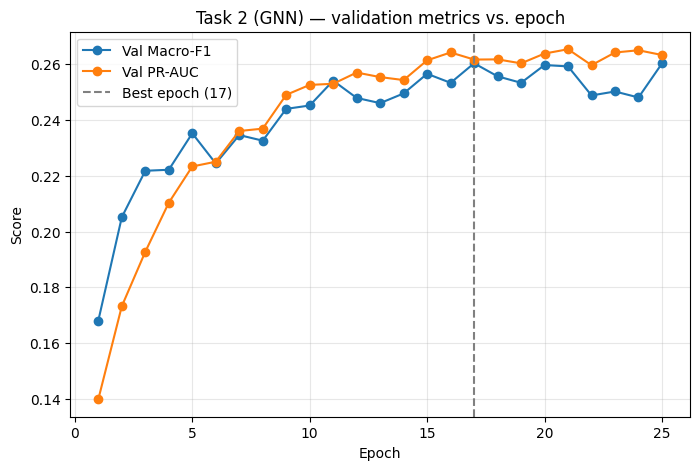

In [36]:
import matplotlib.pyplot as plt

epochs_list = [h["epoch"] for h in gnn_history]
plt.figure(figsize=(8, 5))
plt.plot(epochs_list, [h["val_macro_f1"] for h in gnn_history], marker="o", label="Val Macro-F1")
plt.plot(epochs_list, [h["val_pr_auc"] for h in gnn_history], marker="o", label="Val PR-AUC")
plt.axvline(x=gnn_best_epoch, color="gray", linestyle="--", label=f"Best epoch ({gnn_best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Score"); plt.title("Task 2 (GNN) — validation metrics vs. epoch")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("results/plots/task2_metrics_vs_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

# **Section: GTZAN genre classification : GNN**

# **GTZAN graph dataset and genre classifier head**

In [37]:
class GraphGenreDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        graph = torch.load(f"data/processed/gtzan/{row['clip_id']}.pt", weights_only=False)
        graph.y = torch.tensor([row["label"]], dtype=torch.long)
        return graph


class GNNGenreClassifier(nn.Module):
    def __init__(self, encoder, num_classes=10):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.out_dim, num_classes)
    def forward(self, x, edge_index, batch):
        return self.classifier(self.encoder(x, edge_index, batch))

# **Evaluation and training functions for GTZAN GNN**

In [38]:
from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluate_gtzan(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.cpu())
    all_logits, all_labels = torch.cat(all_logits), torch.cat(all_labels)
    preds = all_logits.argmax(dim=1).numpy()
    labels_np = all_labels.numpy()
    return {
        "accuracy": accuracy_score(labels_np, preds),
        "macro_f1": f1_score(labels_np, preds, average="macro", zero_division=0),
    }


def train_gtzan_gnn(train_df, val_df, test_df, device, num_epochs=60, patience=10):
    train_loader = GeoDataLoader(GraphGenreDataset(train_df), batch_size=16, shuffle=True)
    val_loader = GeoDataLoader(GraphGenreDataset(val_df), batch_size=16, shuffle=False)
    test_loader = GeoDataLoader(GraphGenreDataset(test_df), batch_size=16, shuffle=False)

    encoder = GNNEncoder(in_dim=128, hidden_dim=64, num_layers=2, dropout=0.3)
    model = GNNGenreClassifier(encoder, num_classes=10).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    best_val_f1, best_state, best_epoch, epochs_without_improvement = 0.0, None, None, 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss = loss_fn(logits, batch.y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()

        val_metrics = evaluate_gtzan(model, val_loader, device)
        print(f"[GTZAN] Epoch {epoch+1} | loss: {total_loss/len(train_loader):.4f} | "
              f"val acc: {val_metrics['accuracy']:.4f} | val macro-F1: {val_metrics['macro_f1']:.4f}")

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1, best_epoch = val_metrics["macro_f1"], epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"No improvement for {patience} epochs — stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    test_metrics = evaluate_gtzan(model, test_loader, device)
    print(f"[GTZAN] Final test metrics (best epoch {best_epoch}):", test_metrics)
    return model, test_metrics

# **Train GTZAN GNN and save checkpoint**

In [39]:
gtzan_model, gtzan_metrics = train_gtzan_gnn(gtzan_train, gtzan_val, gtzan_test, device)
torch.save(gtzan_model.state_dict(), "results/checkpoints/gtzan_gnn.pt")
print("GTZAN GNN checkpoint saved.")

[GTZAN] Epoch 1 | loss: 2.2812 | val acc: 0.1000 | val macro-F1: 0.0182
[GTZAN] Epoch 2 | loss: 2.2130 | val acc: 0.1700 | val macro-F1: 0.1132
[GTZAN] Epoch 3 | loss: 2.1404 | val acc: 0.2200 | val macro-F1: 0.1942
[GTZAN] Epoch 4 | loss: 2.0647 | val acc: 0.2400 | val macro-F1: 0.1841
[GTZAN] Epoch 5 | loss: 1.9535 | val acc: 0.2700 | val macro-F1: 0.2468
[GTZAN] Epoch 6 | loss: 1.9004 | val acc: 0.3200 | val macro-F1: 0.3014
[GTZAN] Epoch 7 | loss: 1.8150 | val acc: 0.3600 | val macro-F1: 0.3541
[GTZAN] Epoch 8 | loss: 1.7606 | val acc: 0.3000 | val macro-F1: 0.2794
[GTZAN] Epoch 9 | loss: 1.7008 | val acc: 0.3500 | val macro-F1: 0.3200
[GTZAN] Epoch 10 | loss: 1.6635 | val acc: 0.3300 | val macro-F1: 0.3182
[GTZAN] Epoch 11 | loss: 1.5831 | val acc: 0.3600 | val macro-F1: 0.3289
[GTZAN] Epoch 12 | loss: 1.5233 | val acc: 0.3700 | val macro-F1: 0.3351
[GTZAN] Epoch 13 | loss: 1.4664 | val acc: 0.3600 | val macro-F1: 0.3297
[GTZAN] Epoch 14 | loss: 1.4026 | val acc: 0.4000 | val macr

# **Section: GTZAN genre classification : CNN baseline**

# **Segment-matrix dataset and CNN baseline for GTZAN : GTZANSegmentDataset, CNNGenreBaseline**

In [40]:
class GTZANSegmentDataset(Dataset):
    def __init__(self, df, max_segments=8):
        self.df = df.reset_index(drop=True)
        self.max_segments = max_segments

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        graph = torch.load(f"data/processed/gtzan/{row['clip_id']}.pt", weights_only=False)
        x = graph.x.numpy()
        n_segments = x.shape[0]
        if n_segments >= self.max_segments:
            x = x[:self.max_segments]
        else:
            pad = np.zeros((self.max_segments - n_segments, x.shape[1]), dtype=np.float32)
            x = np.vstack([x, pad])
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(row["label"], dtype=torch.long)
        return x, label


class CNNGenreBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.classifier(h)




# **Training loop for GTZAN CNN baseline**

In [41]:
def train_gtzan_cnn(train_df, val_df, test_df, device, num_epochs=60, patience=10, max_segments=8):
    train_loader = DataLoader(GTZANSegmentDataset(train_df, max_segments), batch_size=16, shuffle=True)
    val_loader = DataLoader(GTZANSegmentDataset(val_df, max_segments), batch_size=16, shuffle=False)
    test_loader = DataLoader(GTZANSegmentDataset(test_df, max_segments), batch_size=16, shuffle=False)

    model = CNNGenreBaseline(num_classes=10).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    best_val_f1, best_state, best_epoch, epochs_without_improvement = 0.0, None, None, 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x, labels in train_loader:
            x, labels = x.to(device), labels.to(device)
            logits = model(x)
            loss = loss_fn(logits, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()

        model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for x, labels in val_loader:
                x = x.to(device)
                all_logits.append(model(x).cpu())
                all_labels.append(labels)
        val_preds = torch.cat(all_logits).argmax(dim=1).numpy()
        val_labels_np = torch.cat(all_labels).numpy()
        val_f1 = f1_score(val_labels_np, val_preds, average="macro", zero_division=0)

        print(f"[GTZAN-CNN] Epoch {epoch+1} | train loss: {total_loss/len(train_loader):.4f} | val macro-F1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1, best_epoch = val_f1, epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"No improvement for {patience} epochs — stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, labels in test_loader:
            x = x.to(device)
            all_logits.append(model(x).cpu())
            all_labels.append(labels)
    test_preds = torch.cat(all_logits).argmax(dim=1).numpy()
    test_labels_np = torch.cat(all_labels).numpy()

    test_metrics = {
        "accuracy": accuracy_score(test_labels_np, test_preds),
        "macro_f1": f1_score(test_labels_np, test_preds, average="macro", zero_division=0),
    }
    print(f"[GTZAN-CNN] Final test metrics (best epoch {best_epoch}):", test_metrics)
    return model, test_metrics



# **Train GTZAN CNN baseline and save checkpoint**

In [42]:
gtzan_cnn_model, gtzan_cnn_metrics = train_gtzan_cnn(gtzan_train, gtzan_val, gtzan_test, device)
torch.save(gtzan_cnn_model.state_dict(), "results/checkpoints/gtzan_cnn.pt")
print("GTZAN CNN checkpoint saved.")

[GTZAN-CNN] Epoch 1 | train loss: 2.3069 | val macro-F1: 0.1004
[GTZAN-CNN] Epoch 2 | train loss: 2.2932 | val macro-F1: 0.0198
[GTZAN-CNN] Epoch 3 | train loss: 2.2741 | val macro-F1: 0.0294
[GTZAN-CNN] Epoch 4 | train loss: 2.2521 | val macro-F1: 0.0924
[GTZAN-CNN] Epoch 5 | train loss: 2.2263 | val macro-F1: 0.1072
[GTZAN-CNN] Epoch 6 | train loss: 2.1951 | val macro-F1: 0.1538
[GTZAN-CNN] Epoch 7 | train loss: 2.1621 | val macro-F1: 0.1859
[GTZAN-CNN] Epoch 8 | train loss: 2.1275 | val macro-F1: 0.2182
[GTZAN-CNN] Epoch 9 | train loss: 2.0932 | val macro-F1: 0.2071
[GTZAN-CNN] Epoch 10 | train loss: 2.0671 | val macro-F1: 0.2133
[GTZAN-CNN] Epoch 11 | train loss: 2.0268 | val macro-F1: 0.1995
[GTZAN-CNN] Epoch 12 | train loss: 2.0047 | val macro-F1: 0.1374
[GTZAN-CNN] Epoch 13 | train loss: 1.9800 | val macro-F1: 0.2156
[GTZAN-CNN] Epoch 14 | train loss: 1.9469 | val macro-F1: 0.2189
[GTZAN-CNN] Epoch 15 | train loss: 1.9270 | val macro-F1: 0.2233
[GTZAN-CNN] Epoch 16 | train loss:

# **Compile and save all Task 2 metrics**

In [43]:
import json

task1_bert_reference = 0.7272  

all_results = {
    "task1_bert_reference": task1_bert_reference,
    "task2_b1_majority": b1_metrics,
    "task2_b2_cnn_mel": b2_metrics,
    "task2_gnn_mtat": gnn_test_metrics,
    "task2_gnn_gtzan_genre": gtzan_metrics,
    "task2_cnn_gtzan_genre": gtzan_cnn_metrics,
}

with open("results/metrics_task2.json", "w") as f:
    json.dump(all_results, f, indent=2, default=float)

print("=== Task 2 final comparison ===")
print(f"B1 (majority-class):        macro-F1 {b1_metrics['macro_f1']:.4f}")
print(f"B2 (CNN-mel, MTAT):         macro-F1 {b2_metrics['macro_f1']:.4f}")
print(f"Task 2 GNN (MTAT tags):     macro-F1 {gnn_test_metrics['macro_f1']:.4f}")
print(f"Task 1 BERT (reference):    macro-F1 {task1_bert_reference:.4f}")
print(f"GTZAN GNN:                  accuracy {gtzan_metrics['accuracy']:.4f}, macro-F1 {gtzan_metrics['macro_f1']:.4f}")
print(f"GTZAN CNN baseline:         accuracy {gtzan_cnn_metrics['accuracy']:.4f}, macro-F1 {gtzan_cnn_metrics['macro_f1']:.4f}")

=== Task 2 final comparison ===
B1 (majority-class):        macro-F1 0.0000
B2 (CNN-mel, MTAT):         macro-F1 0.2152
Task 2 GNN (MTAT tags):     macro-F1 0.2649
Task 1 BERT (reference):    macro-F1 0.7272
GTZAN GNN:                  accuracy 0.3700, macro-F1 0.3765
GTZAN CNN baseline:         accuracy 0.3400, macro-F1 0.3088
